Guides: [How to use SamplerQNN](https://github.com/Qiskit/qiskit-machine-learning/blob/main/docs/tutorials/02_neural_network_classifier_and_regressor.ipynb)

In [1]:
import time as t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

import qiskit
from qiskit.visualization import *
from qiskit.circuit.library import EfficientSU2
import qiskit.circuit as Q
from qiskit.providers.aer import AerSimulator
from qiskit_aer import QasmSimulator
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN


import torch
from torch import cat, no_grad, manual_seed
from torch.optim import Adam
from torch.optim.lr_scheduler import ExponentialLR
from torch.nn import (
 Module, CrossEntropyLoss,
 Conv2d, MaxPool2d,
 Linear, Dropout2d, Flatten, ReLU,
 Sequential, Parameter,
)
import torch.nn.functional as F

from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

from utils import gtt, make_filt

In [2]:
dtype = torch.float32
device = torch.device("mps")
qubits = 4
shots = 512
epochs = 10  # Set number of epochs

print(dtype, device)

torch.float32 mps


In [3]:
# filt, digits = make_filt([for i in range(10)])
filt, digits = make_filt([0,1,2,3,4])

qubits = digits
n_train = 2*digits

print(f'using {qubits} |> @{n_train} points ∈ {filt} for {epochs} epochs')
train_loader, test_loader = gtt(n_train, filt, batch_size=1)

using 5 |> @10 points ∈ [0, 1, 2, 3, 4] for 10 epochs


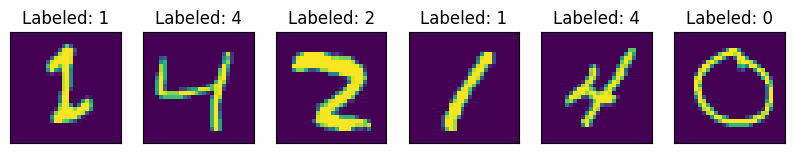

In [4]:
n_samples_show = 6

data_iter = iter(train_loader)
fig, axes = plt.subplots(nrows=1, ncols=n_samples_show, figsize=(10, 3))

while n_samples_show > 0:
    images, targets = data_iter.__next__()

    axes[n_samples_show - 1].imshow(images[0, 0].numpy().squeeze(), cmap="viridis")
    axes[n_samples_show - 1].set_xticks([])
    axes[n_samples_show - 1].set_yticks([])
    axes[n_samples_show - 1].set_title("Labeled: {}".format(targets[0].item()))

    n_samples_show -= 1

In [5]:
def SU2(prefix):
    return EfficientSU2(2, su2_gates=['ry', 'rz'], entanglement='linear', reps=1, parameter_prefix=prefix)

# We use QasmSimulator in parallel
executor = ThreadPoolExecutor(max_workers=8)
# backend = AerSimulator().from_backend("automatic")
backend = QasmSimulator(method="automatic")
backend.set_options(
    executor=executor, max_job_size=1, 
    max_parallel_threads=8,max_parallel_experiments=0, 
    max_parallel_shots=0
)
print(f"{backend}: \n{backend.options}")

qasm_simulator: 
Options(shots=1024, method='automatic', device='CPU', precision='double', executor=<concurrent.futures.thread.ThreadPoolExecutor object at 0x287ce6210>, max_job_size=1, max_shot_size=None, enable_truncation=True, zero_threshold=1e-10, validation_threshold=None, max_parallel_threads=8, max_parallel_experiments=0, max_parallel_shots=0, max_memory_mb=None, fusion_enable=True, fusion_verbose=False, fusion_max_qubit=5, fusion_threshold=14, accept_distributed_results=None, blocking_qubits=None, blocking_enable=False, memory=None, noise_model=None, seed_simulator=None, statevector_parallel_threshold=14, statevector_sample_measure_opt=10, stabilizer_max_snapshot_probabilities=32, extended_stabilizer_sampling_method='resampled_metropolis', extended_stabilizer_metropolis_mixing_time=5000, extended_stabilizer_approximation_error=0.05, extended_stabilizer_norm_estimation_samples=100, extended_stabilizer_norm_estimation_repetitions=3, extended_stabilizer_parallel_threshold=100, ext

In [6]:
# Main convolutional circuit
# Conv -> MaxPool -> Conv -> MaxPool -> Linear
# Conv =
#  \0> ->  H -> Rx -> U [2 at a time] -> CRX [2 -> 1 reduction i,e maxpool] --> repeat till 1 output -> M

def nextPow2(n):
    # decrement `n` (to handle cases when `n` itself
    # is a power of 2)
    n = n - 1
 
    # do till only one bit is left
    while n & n - 1:
        n = n & n - 1       # unset rightmost bit
 
    # `n` is now a power of two (less than `n`)
    # return next power of 2
    return n << 1

def frac(x):
#     print(x)
#     pow2 = nextPow2(x);
#     x = x/pow2
    return x

def QNN(qubits):
    feature_map = qiskit.circuit.library.ZZFeatureMap(qubits)
    print(len(feature_map.parameters))
    ansatz = qiskit.circuit.library.EfficientSU2(
                            qubits, su2_gates=['ry', 'rz'], 
                            entanglement='circular', reps=1
    )
    qc = qiskit.circuit.QuantumCircuit(qubits)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)
    
    qc = qiskit.compiler.transpile(qc, optimization_level=3, backend=backend)
    
    print(f"Circuit Depth {qc.depth()} total {qc.depth()*qubits}")
#     print(qc)

    # REMEMBER TO SET input_gradients=True FOR ENABLING HYBRID GRADIENT BACKPROP
    qnn = SamplerQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True,
        interpret=frac,
        output_shape=10
    )
    return qnn

In [7]:
qnn = QNN(10)

10
Circuit Depth 99 total 990


/opt/homebrew/Caskroom/miniconda/base/envs/qiskit/lib/python3.11/site-packages/numpy/linalg/linalg.py:2154: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/homebrew/Caskroom/miniconda/base/envs/qiskit/lib/python3.11/site-packages/numpy/linalg/linalg.py:2154: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [8]:
class Net(Module):
    def __init__(self, qnn):
        super().__init__()
        self.conv1 = Conv2d(1, 1, kernel_size=3)
        self.dropout = Dropout2d()
        self.fc1 = Linear(169, 10)  # 2-dimensional input to QNN
        self.qnn = TorchConnector(qnn)  # Apply torch connector, weights chosen
        # uniformly at random from interval [-1,1].
        self.fc2 = Linear(10, 10)  # 1-dimensional output from QNN

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        x = x.view(x.shape[0], -1)
        x = self.fc1(x)
        print(x.shape)
        x = self.qnn(x.view(-1))  # apply QNN
        print(x.shape)
        x = self.fc2(x)
        return x; 

In [9]:
model = Net(qnn)
print(model)
print(model(torch.randn(1,28,28)))

Net(
  (conv1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=169, out_features=10, bias=True)
  (qnn): TorchConnector()
  (fc2): Linear(in_features=10, out_features=10, bias=True)
)
torch.Size([1, 10])
NUM_SAMPLES:  1
PROB:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] SHAPE:  (1, 10)
1024
KEY:  (0, 0)
KEY:  (0, 1)
KEY:  (0, 2)
KEY:  (0, 3)
KEY:  (0, 4)
KEY:  (0, 5)
KEY:  (0, 6)
KEY:  (0, 7)
KEY:  (0, 8)
KEY:  (0, 9)
KEY:  (0, 10)


/opt/homebrew/Caskroom/miniconda/base/envs/qiskit/lib/python3.11/site-packages/torch/nn/functional.py:1338: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-wise "


IndexError: index 10 is out of bounds for axis 1 with size 10

In [ ]:
# Define model, optimizer, and loss function
optimizer = Adam(model.parameters(), lr=0.01)
scheduler = ExponentialLR(optimizer, gamma=0.99)

loss_func = CrossEntropyLoss()

# Start training
loss_list = [2.3]  # Store loss history
model.train()  # Set model to training mode

itrs = len(train_loader)
logspan = int(itrs*44/100) # 12%

print(f"Running training for {qubits} Qubits @{itrs} itrs/epoch")

In [ ]:
for epoch in range(epochs):
    total_loss = []
    times = []
    now = t.time()
    
    for batch_idx, (data, target) in enumerate(train_loader):
        z = t.time()
        optimizer.zero_grad(set_to_none=True)  # Initialize gradient
        output = model(data)  # Forward pass
        loss = loss_func(output, target)  # Calculate loss
        loss.backward()  # Backward pass
        
        optimizer.step()  # Optimize weights
        total_loss.append(loss.item())  # Store loss
        z = t.time() - z;
        if ((batch_idx%(logspan))==0): print(f"{int(z)*logspan} sec/{logspan}itrs")
    
    scheduler.step()
    end = int((t.time() - now)/60)+1
    loss_list.append(sum(total_loss) / len(total_loss))
    print("Trained [{:.0f}%]\tLoss: {:.4f}".format(100.0 * (epoch + 1) / epochs, loss_list[-1]), 
          f"in {end} min \t(<{int((epochs-epoch-1)*end)} min left)")
    
    diff = np.abs(loss_list[-1] - loss_list[-2]) /loss_list[-1]; 
    if diff <= 0.0005: # Early stopping criterial loss diff = 0.1%
        print("Τraining Complete")
        break;

In [ ]:
# Plot loss convergence
plt.plot(loss_list)
plt.title("Hybrid NN Training Convergence")
plt.xlabel("Training Iterations")
plt.ylabel("Neg. Log Likelihood Loss")
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    
    correct = 0
    for (data, target) in test_loader:
        output = model4(data)
        
        pred = output.argmax(dim=1, keepdim=True) 
        correct += pred.eq(target.view_as(pred)).sum().item()
        
        loss = loss_func(output, target)
        total_loss.append(loss.item())
        
    print('Performance on test data:\n\tLoss: {:.4f}\n\tAccuracy: {:.1f}%'.format(
                sum(total_loss) / len(total_loss),
                correct / len(test_loader) * 100)
            )
    print(f"\tRandom: {int(100/digits)}%")

In [ ]:
# Plot predicted labels

n_samples_show = 15
count = 0
fig, axes = plt.subplots(nrows=1, ncols=n_samples_show, figsize=(10, 3))

model4.eval()
with no_grad():
    for (data, target) in test_loader:
        if count == n_samples_show:
            break
        output = model4(data[0:1])
        if len(output.shape) == 1:
            output = output.reshape(1, *output.shape)

        pred = output.argmax(dim=1, keepdim=True)

        axes[count].imshow(data[0].numpy().squeeze(), cmap="viridis")

        axes[count].set_xticks([])
        axes[count].set_yticks([])
        axes[count].set_title("{}".format(pred.item()))

        count += 1

In [1]:
from IPython.core.display import HTML
HTML("""
<style>
html{filter:invert(0.86)}

div.prompt{opacity: 0.5;}

.btn-default{border-color: transparent;}

#header-container{display:none !important;}

div.cell.selected, div.cell.selected.jupyter-soft-selected{border-color: transparent;}
</style>
""")